<a href="https://colab.research.google.com/github/Dipesh118/Heart-Disease-Prediction-SHAP-LIME/blob/main/Master_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Imports and Data Cleaning

In [3]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler


# LOAD DATA
df = pd.read_csv("/content/drive/MyDrive/Master Project/Dataset/heart_disease_uci.csv")

# BASIC CLEANING
df = df.drop(columns=["id"])
df["target"] = df["num"].apply(lambda x: 0 if x == 0 else 1)
df = df.drop(columns=["num"])
df = df.drop_duplicates()

# FEATURES / TARGET
X = df.drop(columns=["target"])
y = df["target"]

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

# TRAIN / TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# PREPROCESSING
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)


# TRANSFORM TRAIN / TEST
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Raw feature names from preprocessor
raw_feature_names = preprocessor.get_feature_names_out()

# Remove num__/cat__ prefixes
feature_names = [name.split("__")[-1] for name in raw_feature_names]


# READABLE FEATURE NAME MAPPING
feature_name_map = {
    # Numerical features
    "age": "Age",
    "trestbps": "Resting Blood Pressure",
    "chol": "Cholesterol",
    "thalch": "Maximum Heart Rate",
    "oldpeak": "ST Depression (Oldpeak)",
    "ca": "Number of Major Vessels",

    # Sex
    "sex_Male": "Male",
    "sex_Female": "Female",

    # Chest pain
    "cp_asymptomatic": "Chest Pain (Asymptomatic)",
    "cp_atypical angina": "Chest Pain (Atypical Angina)",
    "cp_non-anginal": "Chest Pain (Non-Anginal)",
    "cp_typical angina": "Chest Pain (Typical Angina)",

    # Fasting blood sugar
    "fbs_True": "High Fasting Blood Sugar",
    "fbs_False": "Normal Fasting Blood Sugar",

    # Resting ECG
    "restecg_normal": "Resting ECG (Normal)",
    "restecg_lv hypertrophy": "Resting ECG (LV Hypertrophy)",
    "restecg_st-t abnormality": "Resting ECG (ST-T Abnormality)",

    # Exercise induced angina
    "exang_True": "Exercise-Induced Angina",
    "exang_False": "No Exercise-Induced Angina",

    # ST slope
    "slope_flat": "ST Slope (Flat)",
    "slope_upsloping": "ST Slope (Upsloping)",
    "slope_downsloping": "ST Slope (Downsloping)",

    # Thal
    "thal_normal": "Thal (Normal)",
    "thal_fixed defect": "Thal (Fixed Defect)",
    "thal_reversable defect": "Thal (Reversible Defect)",

    # Dataset source
    "dataset_Cleveland": "Cleveland Dataset",
    "dataset_Hungary": "Hungary Dataset",
    "dataset_Switzerland": "Switzerland Dataset",
    "dataset_VA Long Beach": "VA Long Beach Dataset"
}

readable_feature_names = [feature_name_map.get(col, col) for col in feature_names]

# Convert to DataFrame
if hasattr(X_train_processed, "toarray"):
    X_train_df = pd.DataFrame(X_train_processed.toarray(), columns=readable_feature_names)
    X_test_df = pd.DataFrame(X_test_processed.toarray(), columns=readable_feature_names)
else:
    X_train_df = pd.DataFrame(X_train_processed, columns=readable_feature_names)
    X_test_df = pd.DataFrame(X_test_processed, columns=readable_feature_names)

# SAVE CLEAN DATA
X_train_df.to_csv("X_train_clean.csv", index=False)
X_test_df.to_csv("X_test_clean.csv", index=False)
y_train.to_csv("y_train.csv", index=False)
y_test.to_csv("y_test.csv", index=False)

# OUTPUTs
print("Data cleaning and preprocessing completed successfully.")
print(f"Final dataset shape: {df.shape}")
print(f"Processed training shape: {X_train_df.shape}")
print(f"Processed testing shape: {X_test_df.shape}")
print(f"Total features after encoding: {len(readable_feature_names)}")

Data cleaning and preprocessing completed successfully.
Final dataset shape: (918, 15)
Processed training shape: (734, 29)
Processed testing shape: (184, 29)
Total features after encoding: 29


MODEL TRAINING AND EVALUATION


Model Performance:
                 Model  Accuracy  Precision  Recall  F1-score     AUC  \
0  Logistic Regression    0.8478     0.8304  0.9118    0.8692  0.9284   
1        Random Forest    0.8370     0.8462  0.8627    0.8544  0.9248   
2              XGBoost    0.8424     0.8476  0.8725    0.8599  0.9067   

   CV Mean Accuracy  CV Std  
0            0.8243  0.0355  
1            0.8161  0.0332  
2            0.7765  0.0394  

Cross-Validation Results:
         Logistic Regression  Random Forest  XGBoost
Fold 1                0.7959         0.7823   0.7823
Fold 2                0.7823         0.7755   0.7415
Fold 3                0.8231         0.8231   0.7483
Fold 4                0.8844         0.8639   0.8503
Fold 5                0.8356         0.8356   0.7603
Mean                  0.8243         0.8161   0.7765
Std Dev               0.0397         0.0371   0.0441


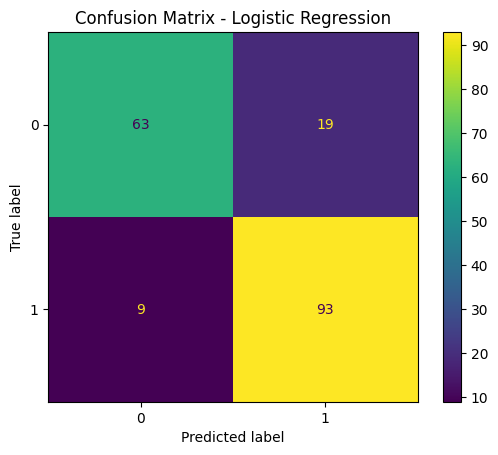

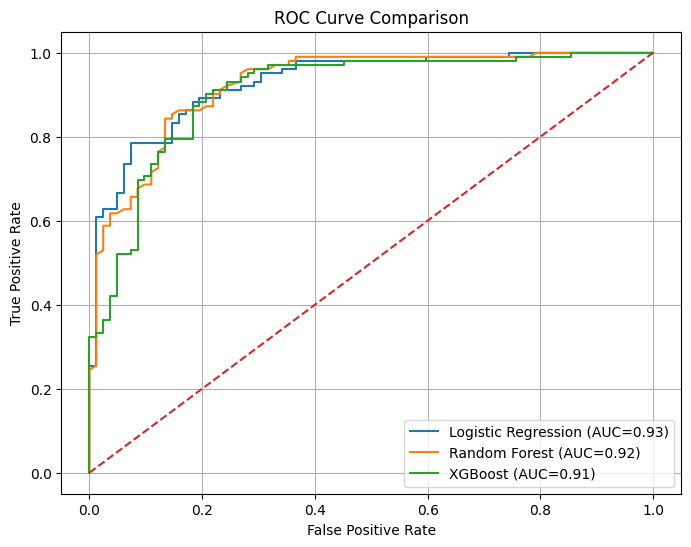

In [4]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve
)

from sklearn.model_selection import cross_val_score, StratifiedKFold

import matplotlib.pyplot as plt
import pandas as pd

# 1. DEFINE MODELS
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "XGBoost": XGBClassifier(
        eval_metric="logloss",
        random_state=42
    )
}

results = []
trained_pipelines = {}
predictions = {}
probabilities = {}
cv_scores_dict = {}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


# 2. TRAIN, TEST, AND EVALUATE
for name, model in models.items():

    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    trained_pipelines[name] = pipeline

    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    predictions[name] = y_pred
    probabilities[name] = y_prob

    cv_scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring="accuracy"
    )
    cv_scores_dict[name] = cv_scores

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_prob),
        "CV Mean Accuracy": cv_scores.mean(),
        "CV Std": cv_scores.std()
    })


# 3. RESULTS TABLE
results_df = pd.DataFrame(results).sort_values(by="AUC", ascending=False)

results_df_display = results_df.copy()
metric_cols = ["Accuracy", "Precision", "Recall", "F1-score", "AUC", "CV Mean Accuracy", "CV Std"]
results_df_display[metric_cols] = results_df_display[metric_cols].round(4)

print("\nModel Performance:")
print(results_df_display)

results_df_display.to_csv("model_results.csv", index=False)


# 4. CROSS-VALIDATION TABLE
cv_table = pd.DataFrame(
    {name: scores for name, scores in cv_scores_dict.items()},
    index=[f"Fold {i+1}" for i in range(5)]
)

cv_table.loc["Mean"] = cv_table.mean()
cv_table.loc["Std Dev"] = cv_table.iloc[:5].std()
cv_table = cv_table.round(4)

print("\nCross-Validation Results:")
print(cv_table)

cv_table.to_csv("cv_results.csv")


# 5. CONFUSION MATRIX (BEST MODEL ONLY)
best_model_name = results_df.iloc[0]["Model"]
best_y_pred = predictions[best_model_name]

cm = confusion_matrix(y_test, best_y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title(f"Confusion Matrix - {best_model_name}")
plt.savefig("confusion_matrix_best_model.png", dpi=300, bbox_inches="tight")
plt.show()


# 6. ROC CURVE
plt.figure(figsize=(8, 6))

for name in models.keys():
    y_prob = probabilities[name]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)

    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.2f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(True)

plt.savefig("roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

EXPLAINABILITY USING SHAP AND LIME

In [5]:
!pip install shap lime -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 7.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


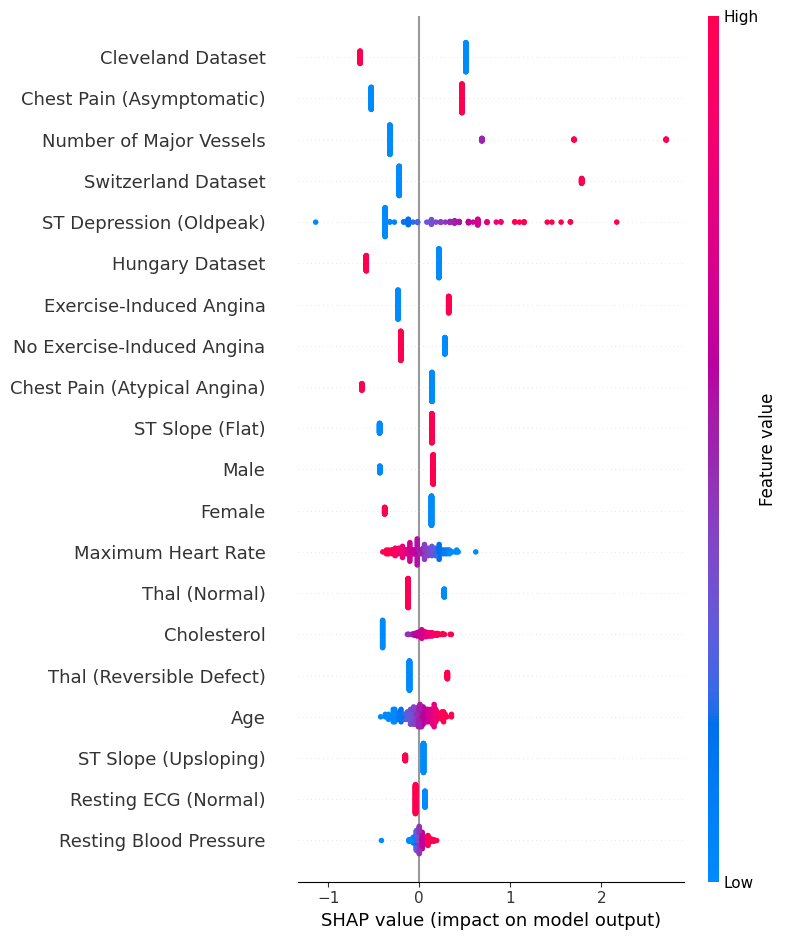

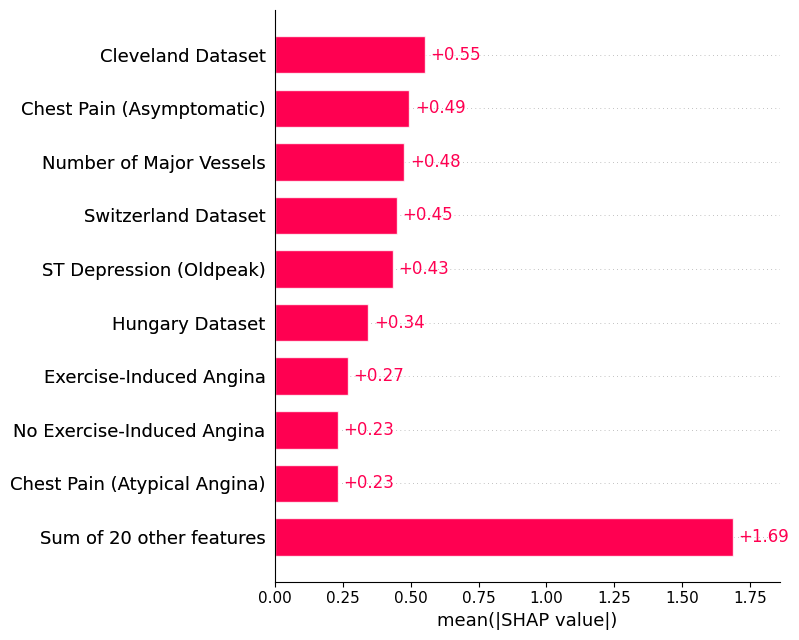

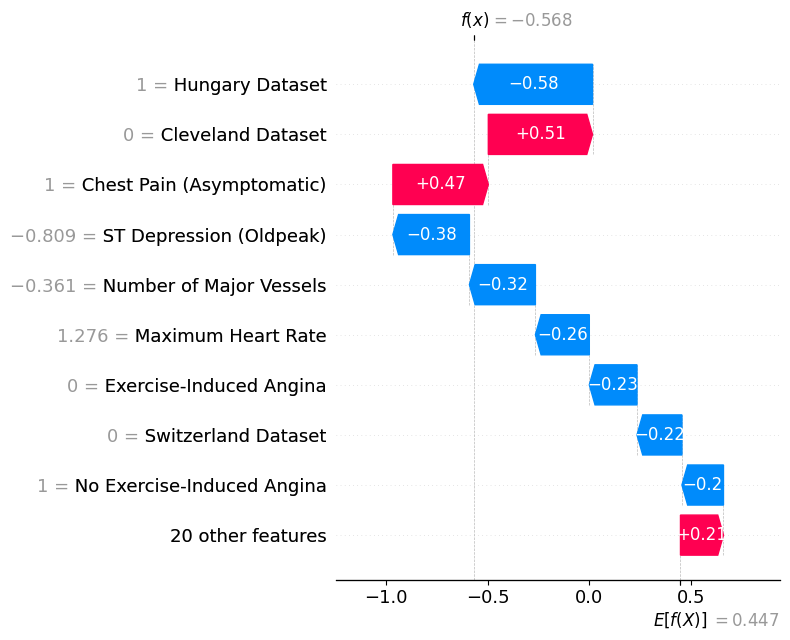

LIME explanation:
Switzerland Dataset <= 0.00: -0.3129
Number of Major Vessels <= -0.36: -0.2208
Cleveland Dataset <= 0.00: 0.2178
0.00 < Chest Pain (Asymptomatic) <= 1.00: 0.1802
0.00 < Hungary Dataset <= 1.00: -0.1443
ST Depression (Oldpeak) <= -0.81: -0.1414
Chest Pain (Atypical Angina) <= 0.00: 0.1396
0.00 < ST Slope (Flat) <= 1.00: 0.1022
Exercise-Induced Angina <= 0.00: -0.0909
Female <= 0.00: 0.0885


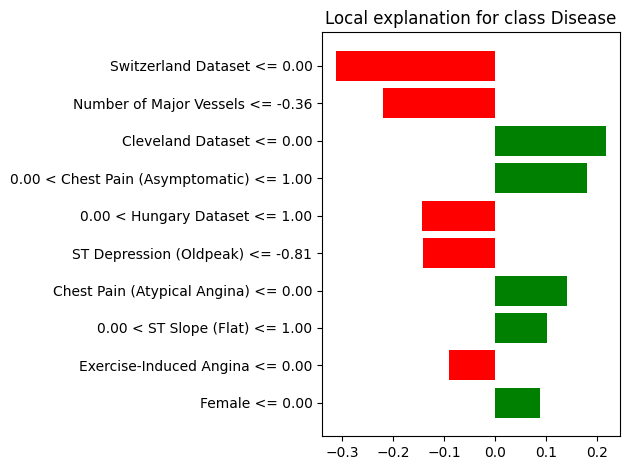

In [6]:
import shap
import lime
import lime.lime_tabular
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from IPython.display import display, HTML


# TRAIN BEST MODEL
lr_model = LogisticRegression(max_iter=2000, random_state=42)
lr_model.fit(X_train_df, y_train)
instance_index = 0


# SHAP EXPLAINABILITY
background = shap.sample(X_train_df, 100, random_state=42)
explainer = shap.Explainer(lr_model, background)
shap_values = explainer(X_test_df)

# SHAP Summary Plot
plt.figure()
shap.summary_plot(shap_values.values, X_test_df, show=False)
plt.tight_layout()
plt.savefig("shap_summary_plot.png", dpi=300, bbox_inches="tight")
plt.show()

# SHAP Bar Plot
plt.figure()
shap.plots.bar(shap_values, max_display=10, show=False)
plt.tight_layout()
plt.savefig("shap_bar_plot.png", dpi=300, bbox_inches="tight")
plt.show()

# SHAP Waterfall Plot
plt.figure()
shap.plots.waterfall(shap_values[instance_index], max_display=10, show=False)
plt.tight_layout()
plt.savefig("shap_waterfall_plot.png", dpi=300, bbox_inches="tight")
plt.show()

# SHAP Force Plot
force_plot = shap.force_plot(
    shap_values[instance_index].base_values,
    shap_values[instance_index].values,
    X_test_df.iloc[instance_index],
    feature_names=X_test_df.columns.tolist()
)
shap.save_html("shap_force_plot.html", force_plot)


# LIME EXPLAINABILITY
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_df.values,
    feature_names=X_train_df.columns.tolist(),
    class_names=["No Disease", "Disease"],
    mode="classification"
)

def predict_proba_with_names(data):
    data_df = pd.DataFrame(data, columns=X_train_df.columns)
    return lr_model.predict_proba(data_df)

lime_exp = lime_explainer.explain_instance(
    data_row=X_test_df.iloc[instance_index].values,
    predict_fn=predict_proba_with_names,
    num_features=10
)

print("LIME explanation:")
for feature, weight in lime_exp.as_list():
    print(f"{feature}: {weight:.4f}")

fig = lime_exp.as_pyplot_figure()
plt.tight_layout()
plt.savefig("lime_plot.png", dpi=300, bbox_inches="tight")
plt.show()

lime_exp.save_to_file("lime_explanation.html")